# 04 · Model 3 - Bidirectional LSTM with GloVe 300d
**Owner:** Akash Shaw · **Family:** recurrent

Embedding layer initialised with GloVe 300d → bidirectional LSTM run over **packed sequences** (padding is skipped) → sequence representation → dropout → linear output (logit).
Two read-outs are compared: the final forward/backward hidden states (`last`) and mean+max pooling over all time steps (`maxmean`).

Why it is in the comparison: gated recurrence (Hochreiter & Schmidhuber, 1997) models **word order and long-range dependencies** such as negation scope and contrast (*"... but in the end it fails"*).

In [1]:
# ---- Setup: runs locally (from notebooks/) or on Google Colab ----
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Keep data and results on Drive so every notebook in the series sees them.
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/dl-sentiment-project")
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"
for d in (RAW, PROC, RESULTS, FIG):
    d.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)

project root: C:\Users\akash\Documents\Study Material\07 Sem7\DL Project


In [2]:
import torch
# ---- Common evaluation protocol (identical in every model notebook) ----
import numpy as np
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

def compute_metrics(y_true, prob):
    y_true, prob = np.asarray(y_true), np.asarray(prob)
    pred = (prob >= 0.5).astype(int)
    return {"accuracy": accuracy_score(y_true, pred), "precision": precision_score(y_true, pred),
            "recall": recall_score(y_true, pred), "f1": f1_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro"), "roc_auc": roc_auc_score(y_true, prob),
            "confusion_matrix": confusion_matrix(y_true, pred).tolist()}

def summarize_runs(runs):
    """Mean and std of test metrics over seeds."""
    keys = ["accuracy", "precision", "recall", "f1", "macro_f1", "roc_auc"]
    vals = {k: [r["test"][k] for r in runs] for k in keys}
    return ({k: float(np.mean(v)) for k, v in vals.items()},
            {k: float(np.std(v)) for k, v in vals.items()})

def save_results(key, result, probs_by_seed, primary_seed=42):
    """results/<key>/metrics.json + per-seed test probabilities (primary seed -> test_probs.npy)."""
    import json
    out = RESULTS / key
    out.mkdir(parents=True, exist_ok=True)
    result["test_mean"], result["test_std"] = summarize_runs(result["runs"])
    (out / "metrics.json").write_text(json.dumps(result, indent=2, default=float))
    for seed, p in probs_by_seed.items():
        np.save(out / f"test_probs_seed{seed}.npy", np.asarray(p, dtype=np.float32))
    np.save(out / "test_probs.npy", np.asarray(probs_by_seed[primary_seed], dtype=np.float32))
    m, s = result["test_mean"], result["test_std"]
    print(f"[{key}] test over {len(result['runs'])} run(s): acc {m['accuracy']:.4f} +/- {s['accuracy']:.4f} | "
          f"F1 {m['f1']:.4f} +/- {s['f1']:.4f} | AUC {m['roc_auc']:.4f}")

In [3]:
# ---- Shared sequence encoding (same tokenizer/vocabulary as notebook 01) ----
import json, re
import pandas as pd

splits = {s: pd.read_csv(PROC / f"{s}.csv") for s in ("train", "val", "test")}
vocab = json.loads((PROC / "vocab.json").read_text())
glove = torch.from_numpy(np.load(PROC / "glove_300d_matrix.npy"))
y = {s: df["label"].values.astype(np.float32) for s, df in splits.items()}
TOKEN = re.compile(r"[a-z0-9]+(?=n't)|n't|'(?:s|m|re|ve|ll|d)\b|[a-z0-9]+|[!?]")
tokens = {s: [TOKEN.findall(t) for t in df["text"]] for s, df in splits.items()}

def encode(toks_list, max_len, strategy):
    """head: first max_len tokens. head_tail: first half + last half (keeps the closing verdict)."""
    out = np.zeros((len(toks_list), max_len), dtype=np.int64)
    unk = vocab["<unk>"]
    for i, toks in enumerate(toks_list):
        if len(toks) > max_len and strategy == "head_tail":
            toks = toks[: max_len // 2] + toks[-(max_len - max_len // 2):]
        ids = [vocab.get(t, unk) for t in toks[:max_len]]
        out[i, : len(ids)] = ids
    return out

_cache = {}
def get_data(max_len=256, strategy="head"):
    key = (max_len, strategy)
    if key not in _cache:
        _cache[key] = {s: (encode(tokens[s], max_len, strategy), y[s]) for s in splits}
    return _cache[key]

print(f"vocab {len(vocab):,} | GloVe matrix {tuple(glove.shape)} | train/val/test "
      f"{len(y['train']):,}/{len(y['val']):,}/{len(y['test']):,}")

vocab 44,912 | GloVe matrix (44912, 300) | train/val/test 22,500/2,500/25,000


In [4]:
# ---- Training loop shared by the GloVe models: Adam + BCE, early stopping on validation F1 ----
import copy, random, time
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEV, torch.cuda.get_device_name(0) if DEV.type == "cuda" else "")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def loader(x, yv, shuffle, seed, bs):
    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(yv))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, generator=torch.Generator().manual_seed(seed))

@torch.no_grad()
def predict(model, dl):
    model.eval()
    return torch.cat([torch.sigmoid(model(x.to(DEV))).float().cpu() for x, _ in dl]).numpy()

def run(cfg, seed=42, verbose=True):
    """Train one configuration with one seed; returns metrics, history, timing and test probabilities."""
    set_seed(seed)
    data = get_data(cfg["max_len"], cfg["truncation"])
    dl = {s: loader(*data[s], shuffle=(s == "train"), seed=seed, bs=cfg["batch_size"]) for s in data}
    model = build_model(cfg).to(DEV)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                           lr=cfg["lr"], weight_decay=cfg.get("weight_decay", 0.0))
    loss_fn = nn.BCEWithLogitsLoss()
    best, best_state, bad, history = -1, None, 0, []
    t0 = time.time()
    for epoch in range(1, cfg["max_epochs"] + 1):
        model.train(); tot = 0.0
        for xb, yb in dl["train"]:
            xb, yb = xb.to(DEV), yb.to(DEV)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if cfg.get("grad_clip"):
                nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step()
            tot += loss.item() * len(yb)
        p_val = predict(model, dl["val"])
        val_loss = float(nn.functional.binary_cross_entropy(torch.tensor(p_val).clamp(1e-6, 1 - 1e-6),
                                                            torch.tensor(data["val"][1])))
        m = compute_metrics(data["val"][1], p_val)
        history.append({"epoch": epoch, "train_loss": tot / len(data["train"][1]), "val_loss": val_loss,
                        "val_acc": m["accuracy"], "val_f1": m["f1"]})
        if verbose:
            print(f"  epoch {epoch:2d} train_loss {history[-1]['train_loss']:.4f} val_loss {val_loss:.4f} "
                  f"val_acc {m['accuracy']:.4f} val_f1 {m['f1']:.4f}")
        if m["f1"] > best:
            best, best_state, bad = m["f1"], copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    train_time = time.time() - t0
    model.load_state_dict(best_state)
    val = compute_metrics(data["val"][1], predict(model, dl["val"]))
    t1 = time.time()
    p_test = predict(model, dl["test"])
    infer_time = time.time() - t1
    n_total = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    del model; torch.cuda.empty_cache()
    return {"seed": seed, "config": cfg, "val": val, "test": compute_metrics(data["test"][1], p_test),
            "history": history, "best_epoch": max(history, key=lambda h: h["val_f1"])["epoch"],
            "train_time_s": train_time, "infer_time_s": infer_time,
            "total_params": n_total, "trainable_params": n_train}, p_test

def row(name, r):
    return {"variant": name, "val_f1": r["val"]["f1"], "val_acc": r["val"]["accuracy"],
            "test_acc": r["test"]["accuracy"], "test_f1": r["test"]["f1"],
            "best_epoch": r["best_epoch"], "train_time_s": round(r["train_time_s"], 1)}

device: cuda NVIDIA GeForce RTX 3050 Laptop GPU


## Model definition

In [5]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class BiLSTM(nn.Module):
    def __init__(self, embeddings, hidden, layers, dropout, freeze, pooling):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(embeddings.clone(), freeze=freeze, padding_idx=0)
        self.lstm = nn.LSTM(embeddings.shape[1], hidden, num_layers=layers, batch_first=True,
                            bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.pooling = pooling
        self.fc = nn.Linear(hidden * (2 if pooling == "last" else 4), 1)

    def forward(self, x):
        mask = x != 0
        lengths = mask.sum(1).clamp(min=1)
        packed = pack_padded_sequence(self.dropout(self.embedding(x)), lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        out, (h, _) = self.lstm(packed)
        if self.pooling == "last":
            # forward state after the last real token + backward state after the first token
            feat = torch.cat([h[-2], h[-1]], dim=1)
        else:
            out, _ = pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
            m = mask.unsqueeze(-1)
            mean = (out * m).sum(1) / lengths.unsqueeze(1)
            mx = out.masked_fill(~m, -1e4).amax(1)
            feat = torch.cat([mean, mx], dim=1)
        return self.fc(self.dropout(feat)).squeeze(1)

def build_model(cfg):
    return BiLSTM(glove, cfg["hidden"], cfg["layers"], cfg["dropout"], cfg["freeze"], cfg["pooling"])

BASE = {"max_len": 256, "truncation": "head", "freeze": False, "hidden": 128, "layers": 1, "pooling": "last",
        "dropout": 0.5, "lr": 1e-3, "grad_clip": 1.0, "batch_size": 64, "max_epochs": 10, "patience": 3}
SEARCH = {
    "1x128, last state": BASE,
    "1x256, last state": {**BASE, "hidden": 256},
    "2x128, last state": {**BASE, "layers": 2},
    "1x128, mean+max pool": {**BASE, "pooling": "maxmean"},
}
KEY, MODEL_NAME, OWNER, FAMILY = "lstm", "BiLSTM (GloVe 300d)", "Akash Shaw", "Recurrent"

In [6]:
# ---- Experiment protocol (identical for the CNN and BiLSTM notebooks) ----
# Stage 1: 4-configuration search (head truncation, 256 tokens, fine-tuned GloVe), selected on val F1.
# Stage 2: ablations around the best configuration:
#          head+tail truncation (256), frozen GloVe (256), and a 512-token context (reported only -
#          the main comparison keeps the 256-token budget fixed in the synopsis).
# Stage 3: the best 256-token variant (by val F1) is re-trained with seeds 42, 43, 44.
SEEDS = [42, 43, 44]
search_rows, ablation_rows, runs_cache = [], [], {}

def run_cached(name, cfg, seed=42):
    key = (json.dumps(cfg, sort_keys=True), seed)
    if key not in runs_cache:
        print(f"> {name} (seed {seed})")
        runs_cache[key] = run(cfg, seed)
    return runs_cache[key]

In [7]:
# Stage 1 - hyper-parameter search
for name, cfg in SEARCH.items():
    r, _ = run_cached(name, cfg)
    search_rows.append(row(name, r))
search_df = pd.DataFrame(search_rows).sort_values("val_f1", ascending=False)
display(search_df)
best_name = search_df.iloc[0]["variant"]
best_cfg = SEARCH[best_name]
print("selected:", best_name)

> 1x128, last state (seed 42)


  epoch  1 train_loss 0.5229 val_loss 0.4347 val_acc 0.8068 val_f1 0.8178


  epoch  2 train_loss 0.3407 val_loss 0.3346 val_acc 0.8640 val_f1 0.8543


  epoch  3 train_loss 0.2110 val_loss 0.3074 val_acc 0.8816 val_f1 0.8769


  epoch  4 train_loss 0.1376 val_loss 0.4307 val_acc 0.8732 val_f1 0.8774


...

  epoch  4 train_loss 0.0982 val_loss 0.3351 val_acc 0.8820 val_f1 0.8775


  epoch  5 train_loss 0.0622 val_loss 0.4310 val_acc 0.8788 val_f1 0.8773


  epoch  6 train_loss 0.0340 val_loss 0.5329 val_acc 0.8724 val_f1 0.8728


,variant,val_f1,val_acc,test_acc,test_f1,best_epoch,train_time_s
3,"1x128, mean+max pool",0.886208,0.8868,0.87356,0.869180,3,210.9
0,"1x128, last state",0.877989,0.8796,0.84536,0.836464,6,260.9
2,"2x128, last state",0.877890,0.8796,0.86028,0.853660,4,337.4
1,"1x256, last state",0.875658,0.8772,0.83648,0.828365,10,299.6


selected: 1x128, mean+max pool


In [8]:
# Stage 2 - ablations around the selected configuration
variants = {
    "head 256 (selected)": best_cfg,
    "head+tail 256": {**best_cfg, "truncation": "head_tail"},
    "frozen GloVe, head 256": {**best_cfg, "freeze": True},
    "head 512": {**best_cfg, "max_len": 512},
}
for name, cfg in variants.items():
    r, _ = run_cached(name, cfg)
    ablation_rows.append(row(name, r))
ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df)

# final configuration: best validation F1 among the 256-token variants
eligible = ablation_df[~ablation_df["variant"].str.contains("512")]
final_name = eligible.sort_values("val_f1", ascending=False).iloc[0]["variant"]
final_cfg = variants[final_name]
print("final configuration:", final_name, final_cfg)

> head+tail 256 (seed 42)


  epoch  1 train_loss 0.4273 val_loss 0.3223 val_acc 0.8656 val_f1 0.8729


  epoch  2 train_loss 0.2444 val_loss 0.2973 val_acc 0.8800 val_f1 0.8724


  epoch  3 train_loss 0.1564 val_loss 0.2839 val_acc 0.8864 val_f1 0.8904


  epoch  4 train_loss 0.0915 val_loss 0.3515 val_acc 0.8884 val_f1 0.8828


...

  epoch  4 train_loss 0.0939 val_loss 0.3096 val_acc 0.8924 val_f1 0.8901


  epoch  5 train_loss 0.0548 val_loss 0.4161 val_acc 0.8848 val_f1 0.8878


  epoch  6 train_loss 0.0329 val_loss 0.4874 val_acc 0.8840 val_f1 0.8837


,variant,val_f1,val_acc,test_acc,test_f1,best_epoch,train_time_s
0,head 256 (selected),0.886208,0.8868,0.87356,0.869180,3,210.9
1,head+tail 256,0.890432,0.8864,0.88432,0.887155,3,221.6
2,"frozen GloVe, head 256",0.885692,0.8824,0.88848,0.891980,10,277.9
3,head 512,0.891260,0.8940,0.87924,0.872997,3,385.5


final configuration: head+tail 256 {'max_len': 256, 'truncation': 'head_tail', 'freeze': False, 'hidden': 128, 'layers': 1, 'pooling': 'maxmean', 'dropout': 0.5, 'lr': 0.001, 'grad_clip': 1.0, 'batch_size': 64, 'max_epochs': 10, 'patience': 3}


In [9]:
# Stage 3 - final configuration with three seeds
runs, probs = [], {}
for seed in SEEDS:
    r, p = run_cached(final_name, final_cfg, seed)
    runs.append(r); probs[seed] = p
    print(f"seed {seed}: test acc {r['test']['accuracy']:.4f} F1 {r['test']['f1']:.4f}")

save_results(KEY, {
    "model": MODEL_NAME, "owner": OWNER, "family": FAMILY,
    "final_variant": final_name, "config": final_cfg,
    "search": search_rows, "ablations": ablation_rows,
    "total_params": runs[0]["total_params"], "trainable_params": runs[0]["trainable_params"],
    "runs": runs,
}, probs)

seed 42: test acc 0.8843 F1 0.8872
> head+tail 256 (seed 43)


  epoch  1 train_loss 0.4202 val_loss 0.2942 val_acc 0.8712 val_f1 0.8712


  epoch  2 train_loss 0.2418 val_loss 0.2934 val_acc 0.8852 val_f1 0.8820


  epoch  3 train_loss 0.1517 val_loss 0.2784 val_acc 0.8876 val_f1 0.8908


  epoch  4 train_loss 0.0930 val_loss 0.3469 val_acc 0.8896 val_f1 0.8907


...

  epoch  3 train_loss 0.1562 val_loss 0.2984 val_acc 0.8956 val_f1 0.8962


  epoch  4 train_loss 0.0926 val_loss 0.3281 val_acc 0.8852 val_f1 0.8817


  epoch  5 train_loss 0.0550 val_loss 0.3840 val_acc 0.8864 val_f1 0.8859


  epoch  6 train_loss 0.0371 val_loss 0.4596 val_acc 0.8820 val_f1 0.8828


seed 44: test acc 0.8844 F1 0.8836
[lstm] test over 3 run(s): acc 0.8848 +/- 0.0006 | F1 0.8860 +/- 0.0017 | AUC 0.9551


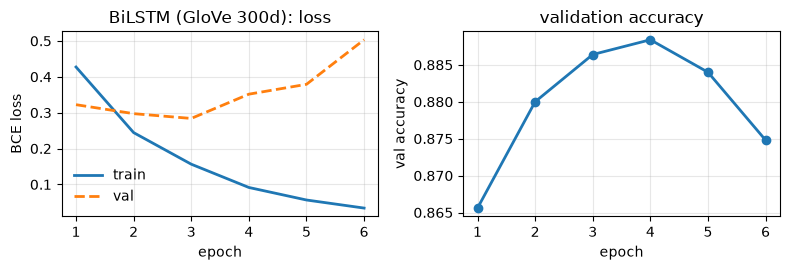

In [10]:
# Learning curves of the primary (seed 42) final run
import matplotlib.pyplot as plt
h = pd.DataFrame(runs[0]["history"])
fig, ax = plt.subplots(1, 2, figsize=(8, 2.8))
ax[0].plot(h.epoch, h.train_loss, lw=2, label="train"); ax[0].plot(h.epoch, h.val_loss, lw=2, ls="--", label="val")
ax[0].set(xlabel="epoch", ylabel="BCE loss", title=f"{MODEL_NAME}: loss"); ax[0].legend(frameon=False)
ax[1].plot(h.epoch, h.val_acc, lw=2, marker="o"); ax[1].set(xlabel="epoch", ylabel="val accuracy", title="validation accuracy")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Ablation note

The BiLSTM experiment keeps the tokenisation and split contract shared with the other models. Pooling variants are compared using the same seeds so changes in validation performance can be attributed to the pooling choice.
